# Treinamento EfficientNet-B0 — C-NMC 2019

Classificação binária de imagens celulares:

- 0: normal;
- 1: maligna — LLA-B.

Divisão por pacientes:

- treino: folds 0 e 1;
- validação: fold 2;
- teste final: conjunto preliminar.

O conjunto de teste não será utilizado durante o treinamento.

In [1]:
# Cell 1
!pip install -q kagglehub scikit-learn seaborn

KeyboardInterrupt: 

In [2]:
# Cell 2
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"

import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as error:
    print("Determinismo parcial:", error)

gpus = tf.config.list_physical_devices("GPU")

print("TensorFlow:", tf.__version__)
print("GPUs encontradas:", gpus)

assert gpus, (
    "Nenhuma GPU encontrada. "
    "Ative a GPU T4 nas configurações do Colab."
)

TensorFlow: 2.20.0
GPUs encontradas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Cell 3
from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/IT_2026"
)

METADATA_DIR = DRIVE_ROOT / "datasets" / "cnmc"

EXPERIMENT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "efficientnet_b0_cnmc"
)

CHECKPOINT_DIR = EXPERIMENT_DIR / "checkpoints"
FIGURES_DIR = EXPERIMENT_DIR / "figures"
LOGS_DIR = EXPERIMENT_DIR / "logs"

for directory in [
    EXPERIMENT_DIR,
    CHECKPOINT_DIR,
    FIGURES_DIR,
    LOGS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed": SEED,
    "image_size": [224, 224],
    "batch_size": 32,
    "classes": {
        "0": "normal",
        "1": "malignant",
    },
    "backbone": "EfficientNetB0",
    "pretrained_weights": "imagenet",
    "initial_learning_rate": 1e-3,
    "initial_epochs": 15,
    "train_source": ["fold_0", "fold_1"],
    "validation_source": ["fold_2"],
    "test_source": "preliminary_test",
}

with (EXPERIMENT_DIR / "training_config.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        CONFIG,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Experimento:", EXPERIMENT_DIR)

Mounted at /content/drive
Experimento: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc


In [4]:
# Cell 4
import kagglehub
from pathlib import Path


DATA_DIR = Path("/content/cnmc")

download_path = kagglehub.dataset_download(
    "shafiullahshafin/c-nmc-2019-dataset",
    output_dir=str(DATA_DIR),
)

package_directories = [
    path
    for path in DATA_DIR.rglob("C-NMC 2019 (PKG)")
    if path.is_dir()
    and (
        path / "C-NMC_training_data"
    ).is_dir()
]

assert package_directories, (
    "A pasta 'C-NMC 2019 (PKG)' não foi encontrada."
)

PACKAGE_DIR = package_directories[0]

# The 'relative_path' in the CSVs (e.g., 'C-NMC_training_data/...')
# is relative to the 'C-NMC 2019 (PKG)' folder.
# Therefore, the DATASET_ROOT should be PACKAGE_DIR itself.
DATASET_ROOT = PACKAGE_DIR

print("Retorno do KaggleHub:", download_path)
print("Pasta do pacote:", PACKAGE_DIR)
print("Raiz utilizada:", DATASET_ROOT)
print(
    "Imagens BMP:",
    len(list(PACKAGE_DIR.rglob("*.bmp"))),
)

100%|██████████| 868M/868M [00:41<00:00, 22.0MB/s]

Extracting files...


Retorno do KaggleHub: /content/cnmc
Pasta do pacote: /content/cnmc/C-NMC 2019 (PKG)
Raiz utilizada: /content/cnmc/C-NMC 2019 (PKG)
Imagens BMP: 15114


In [5]:
# Cell 5
from pathlib import Path
from google.colab import drive


drive.mount(
    "/content/drive",
    force_remount=False,
)

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/IT_2026"
)

METADATA_DIR = (
    DRIVE_ROOT
    / "datasets"
    / "cnmc"
)

EXPERIMENT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "efficientnet_b0_cnmc"
)

CHECKPOINT_DIR = (
    EXPERIMENT_DIR
    / "checkpoints"
)

FIGURES_DIR = (
    EXPERIMENT_DIR
    / "figures"
)

LOGS_DIR = (
    EXPERIMENT_DIR
    / "logs"
)

for directory in [
    EXPERIMENT_DIR,
    CHECKPOINT_DIR,
    FIGURES_DIR,
    LOGS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Metadados:", METADATA_DIR)
print(
    "CSV de treino existe:",
    (
        METADATA_DIR
        / "cnmc_train.csv"
    ).exists(),
)

print("Experimento:", EXPERIMENT_DIR)

SEED = 42

CONFIG = {
    "seed": SEED,
    "image_size": [224, 224],
    "batch_size": 32,
    "classes": {
        "0": "normal",
        "1": "malignant",
    },
    "backbone": "EfficientNetB0",
    "pretrained_weights": "imagenet",
    "initial_learning_rate": 1e-3,
    "initial_epochs": 15,
    "train_source": [
        "fold_0",
        "fold_1",
    ],
    "validation_source": [
        "fold_2",
    ],
    "test_source": "preliminary_test",
}

tf.keras.utils.set_random_seed(SEED)

print("Configuração recuperada:")
print(CONFIG)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Metadados: /content/drive/MyDrive/IT_2026/datasets/cnmc
CSV de treino existe: True
Experimento: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc
Configuração recuperada:
{'seed': 42, 'image_size': [224, 224], 'batch_size': 32, 'classes': {'0': 'normal', '1': 'malignant'}, 'backbone': 'EfficientNetB0', 'pretrained_weights': 'imagenet', 'initial_learning_rate': 0.001, 'initial_epochs': 15, 'train_source': ['fold_0', 'fold_1'], 'validation_source': ['fold_2'], 'test_source': 'preliminary_test'}


In [6]:
# Cell 6
LABEL_MAP = {
    "normal": 0,
    "malignant": 1,
}

SPLIT_FILES = {
    "train": METADATA_DIR / "cnmc_train.csv",
    "validation": METADATA_DIR / "cnmc_validation.csv",
    "test": METADATA_DIR / "cnmc_test.csv",
}


def load_split(split_name):
    csv_path = SPLIT_FILES[split_name]

    assert csv_path.exists(), (
        f"CSV não encontrado: {csv_path}"
    )

    dataframe = pd.read_csv(csv_path)

    dataframe["relative_path"] = (
        dataframe["relative_path"]
        .astype(str)
        .str.replace("\\", "/", regex=False)
    )

    # Re-evaluate image_path using the correctly set DATASET_ROOT
    dataframe["image_path"] = dataframe[
        "relative_path"
    ].apply(
        lambda path: str(DATASET_ROOT / path)
    )

    dataframe["label"] = dataframe[
        "class_name"
    ].map(LABEL_MAP)

    assert dataframe["label"].notna().all(), (
        f"Classe desconhecida no conjunto {split_name}"
    )

    dataframe["label"] = dataframe[
        "label"
    ].astype("int32")

    return dataframe


train_df = load_split("train")
validation_df = load_split("validation")
test_df = load_split("test")

print("Treino:", len(train_df))
print("Validação:", len(validation_df))
print("Teste:", len(test_df))

Treino: 7108
Validação: 3553
Teste: 1867


In [7]:
# Cell 7
splits = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}

for split_name, dataframe in splits.items():
    missing_files = dataframe[
        "image_path"
    ].apply(
        lambda path: not Path(path).is_file()
    )

    print(
        split_name,
        "| imagens:",
        len(dataframe),
        "| pacientes:",
        dataframe["subject_id"].nunique(),
        "| ausentes:",
        int(missing_files.sum()),
    )

    assert not missing_files.any(), (
        f"Existem imagens ausentes em {split_name}"
    )

train_subjects = set(train_df["subject_id"])
validation_subjects = set(validation_df["subject_id"])
test_subjects = set(test_df["subject_id"])

assert train_subjects.isdisjoint(validation_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert validation_subjects.isdisjoint(test_subjects)

print(
    "Divisão aprovada: nenhum paciente compartilhado."
)

train | imagens: 7108 | pacientes: 42 | ausentes: 0
validation | imagens: 3553 | pacientes: 31 | ausentes: 0
test | imagens: 1867 | pacientes: 28 | ausentes: 0
Divisão aprovada: nenhum paciente compartilhado.


In [8]:
# Cell 8
distribution = pd.concat(
    [
        dataframe.assign(split=split_name)
        for split_name, dataframe in splits.items()
    ],
    ignore_index=True,
)

summary = (
    distribution
    .groupby(["split", "class_name"])
    .agg(
        images=("relative_path", "count"),
        subjects=("subject_id", "nunique"),
    )
    .reset_index()
)

display(summary)

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].to_numpy(),
)

CLASS_WEIGHT = {
    int(label): float(weight)
    for label, weight in zip(classes, weights)
}

print("Pesos das classes:", CLASS_WEIGHT)

,split,class_name,images,subjects
0,test,malignant,1219,13
1,test,normal,648,15
2,train,malignant,4815,30
3,train,normal,2293,12
4,validation,malignant,2457,17
5,validation,normal,1096,14


Pesos das classes: {0: 1.5499345835150458, 1: 0.7381100726895119}


In [9]:
# Cell 9
IMAGE_SIZE = tuple(CONFIG["image_size"])
BATCH_SIZE = CONFIG["batch_size"]
AUTOTUNE = tf.data.AUTOTUNE


def decode_and_resize(image_path, label):
    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_bmp(
        image_bytes,
        channels=3,
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        antialias=True,
    )

    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def make_dataset(dataframe, training=False):
    paths = dataframe[
        "image_path"
    ].astype(str).to_numpy()

    labels = dataframe[
        "label"
    ].to_numpy(dtype=np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        decode_and_resize,
        num_parallel_calls=AUTOTUNE,
        deterministic=True,
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False,
    )

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = make_dataset(
    train_df,
    training=True,
)

validation_dataset = make_dataset(
    validation_df,
)

test_dataset = make_dataset(
    test_df,
)

In [ ]:
# Cell 10
images, labels = next(iter(train_dataset))

print("Formato das imagens:", images.shape)
print("Formato dos rótulos:", labels.shape)
print("Pixel mínimo:", float(tf.reduce_min(images)))
print("Pixel máximo:", float(tf.reduce_max(images)))
print("Rótulos:", np.unique(labels.numpy()))

assert images.shape[1:] == (224, 224, 3)
assert float(tf.reduce_min(images)) >= 0
assert float(tf.reduce_max(images)) <= 255
assert set(np.unique(labels.numpy())).issubset(
    {0.0, 1.0}
)

Formato das imagens: (32, 224, 224, 3)
Formato dos rótulos: (32,)
Pixel mínimo: 0.0
Pixel máximo: 144.4779815673828
Rótulos: [0. 1.]


In [ ]:
# Cell 11
FROZEN_MODEL_PATH = (
    CHECKPOINT_DIR
    / "best_frozen.keras"
)

FROZEN_HISTORY_PATH = (
    LOGS_DIR
    / "frozen_training_history.csv"
)

print(
    "Checkpoint existe:",
    FROZEN_MODEL_PATH.exists(),
)

print(
    "Histórico existe:",
    FROZEN_HISTORY_PATH.exists(),
)

print("\nCheckpoints disponíveis:")

for path in CHECKPOINT_DIR.glob("*"):
    print(
        "-",
        path.name,
        f"({path.stat().st_size / 1024**2:.1f} MB)",
    )

assert FROZEN_MODEL_PATH.exists(), (
    f"Checkpoint não encontrado: {FROZEN_MODEL_PATH}"
)

frozen_model = tf.keras.models.load_model(
    FROZEN_MODEL_PATH
)

print("Modelo recuperado com sucesso.")

Checkpoint existe: True
Histórico existe: True

Checkpoints disponíveis:
- best_frozen.keras (16.3 MB)
Modelo recuperado com sucesso.


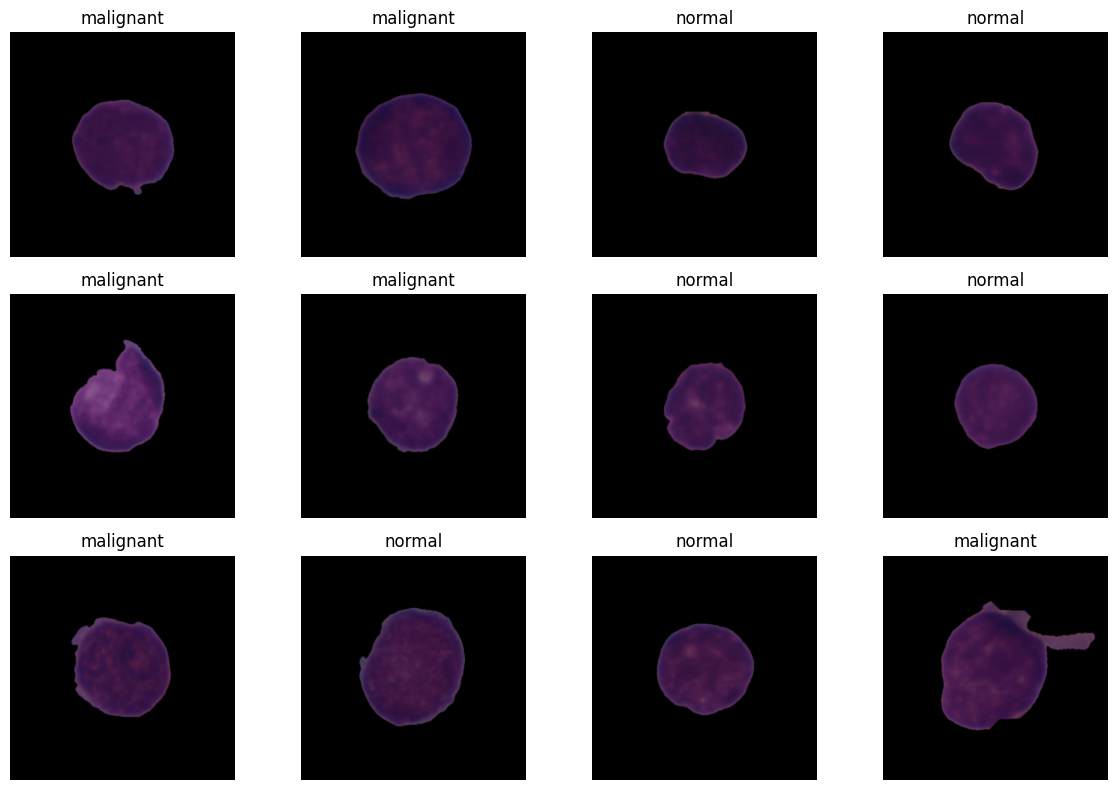

In [ ]:
# Cell 12
CLASS_NAMES = {
    0: "normal",
    1: "malignant",
}

plt.figure(figsize=(12, 8))

for index in range(12):
    plt.subplot(3, 4, index + 1)
    plt.imshow(
        tf.cast(images[index], tf.uint8)
    )

    label = int(labels[index].numpy())

    plt.title(CLASS_NAMES[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Data Augmentation

In [ ]:
# Cell 13
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal_and_vertical",
            seed=SEED,
        ),
        tf.keras.layers.RandomRotation(
            factor=0.05,
            seed=SEED,
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            seed=SEED,
        ),
        tf.keras.layers.RandomContrast(
            factor=0.10,
            seed=SEED,
        ),
    ],
    name="data_augmentation",
)

# EfficientNet-B0

In [ ]:
# Cell 14
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="image",
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False,
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling",
)(x)

x = tf.keras.layers.Dropout(
    rate=0.30,
    name="dropout",
)(x)

outputs = tf.keras.layers.Dense(
    units=1,
    activation="sigmoid",
    dtype="float32",
    name="malignant_probability",
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="efficientnet_b0_cnmc",
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnet_b0_cnmc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malignant_probability (Dense)   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Cell 15
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=CONFIG[
            "initial_learning_rate"
        ],
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.Precision(
            name="precision",
        ),
        tf.keras.metrics.Recall(
            name="recall",
        ),
        tf.keras.metrics.AUC(
            name="auc",
        ),
    ],
)

trainable_parameters = sum(
    np.prod(variable.shape)
    for variable in model.trainable_weights
)

non_trainable_parameters = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
)

print(
    "Parâmetros treináveis:",
    f"{trainable_parameters:,}",
)

print(
    "Parâmetros congelados:",
    f"{non_trainable_parameters:,}",
)

print(
    "Backbone treinável:",
    base_model.trainable,
)

Parâmetros treináveis: 1,281
Parâmetros congelados: 4,049,571.0
Backbone treinável: False


In [ ]:
# Cell 16
FROZEN_MODEL_PATH = (
    CHECKPOINT_DIR
    / "best_frozen.keras"
)

FROZEN_HISTORY_PATH = (
    LOGS_DIR
    / "frozen_training_history.csv"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(FROZEN_MODEL_PATH),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename=str(FROZEN_HISTORY_PATH),
        append=False,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

print("Checkpoint:", FROZEN_MODEL_PATH)
print("Histórico:", FROZEN_HISTORY_PATH)

Checkpoint: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/checkpoints/best_frozen.keras
Histórico: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/logs/frozen_training_history.csv


In [ ]:
# Cell 17
history_frozen = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=CONFIG["initial_epochs"],
    class_weight=CLASS_WEIGHT,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7017 - auc: 0.7521 - loss: 0.5738 - precision: 0.8200 - recall: 0.7258
Epoch 1: val_auc improved from None to 0.74462, saving model to /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/checkpoints/best_frozen.keras

Epoch 1: finished saving model to /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/checkpoints/best_frozen.keras
223/223 ━━━━━━━━━━━━━━━━━━━━ 82s 287ms/step - accuracy: 0.7442 - auc: 0.8134 - loss: 0.5292 - precision: 0.8500 - recall: 0.7558 - val_accuracy: 0.7287 - val_auc: 0.7446 - val_loss: 0.5502 - val_precision: 0.7973 - val_recall: 0.8148 - learning_rate: 0.0010
Epoch 2/15
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7824 - auc: 0.8511 - loss: 0.4830 - precision: 0.8720 - recall: 0.7916
Epoch 2: val_auc improved from 0.74462 to 0.76381, saving model to /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/checkpoints/best_frozen.keras

Epoch 2: finish

In [ ]:
# Cell 18
history_data = {
    metric: [
        float(value)
        for value in values
    ]
    for metric, values
    in history_frozen.history.items()
}

with (
    LOGS_DIR
    / "frozen_training_history.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        history_data,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Histórico salvo.")

Histórico salvo.


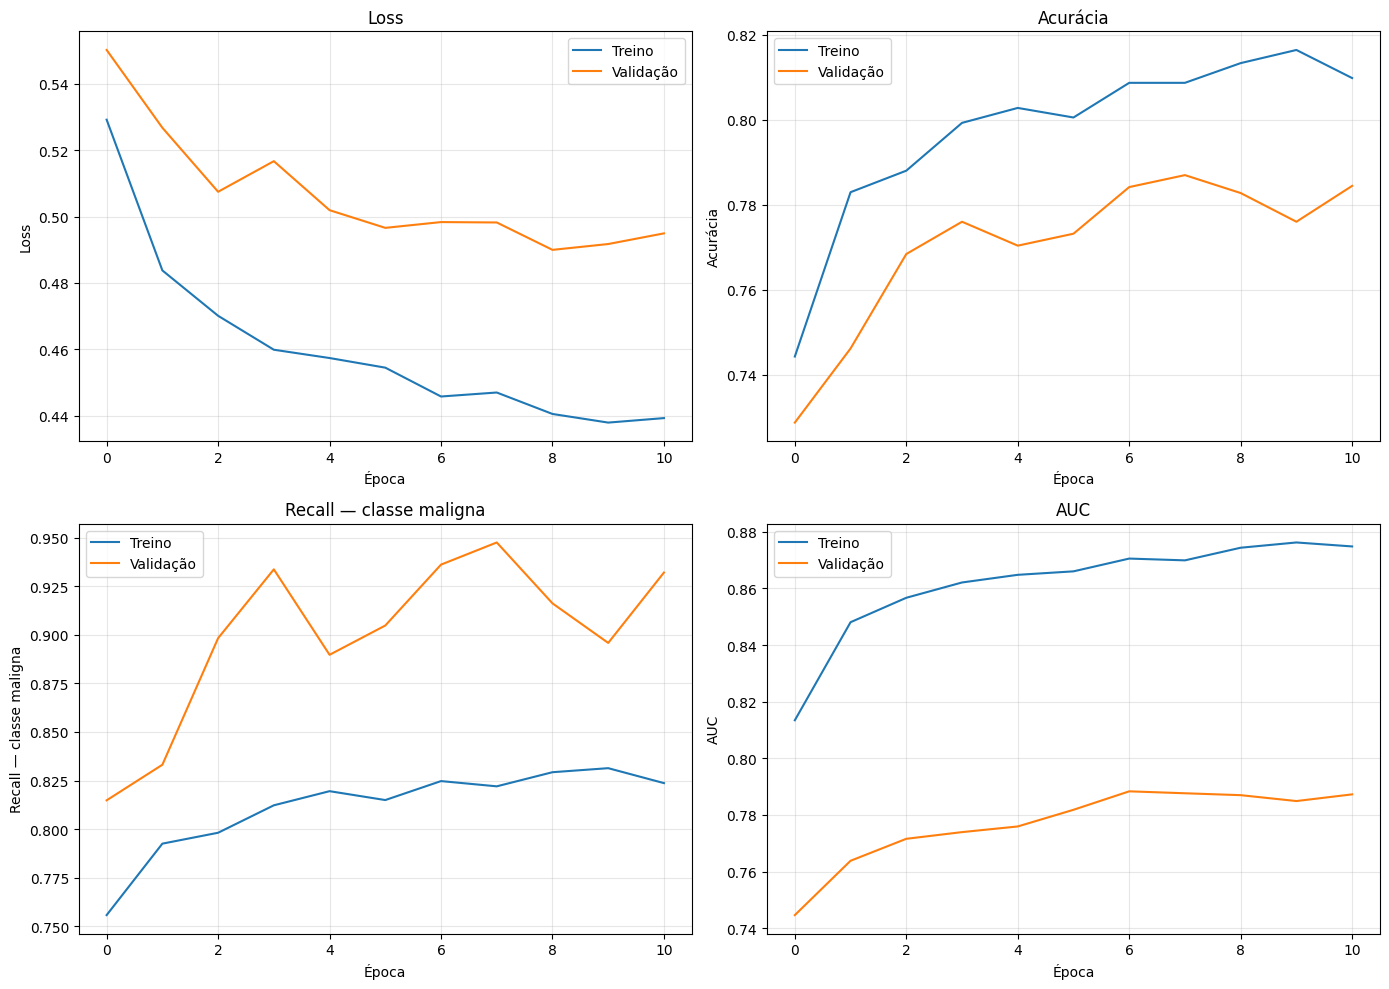

Figura salva em: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/figures/frozen_training_curves.png


In [ ]:
# Cell 19
metrics_to_plot = [
    ("loss", "Loss"),
    ("accuracy", "Acurácia"),
    ("recall", "Recall — classe maligna"),
    ("auc", "AUC"),
]

plt.figure(figsize=(14, 10))

for index, (metric, title) in enumerate(
    metrics_to_plot,
    start=1,
):
    plt.subplot(2, 2, index)

    plt.plot(
        history_frozen.history[metric],
        label="Treino",
    )

    plt.plot(
        history_frozen.history[f"val_{metric}"],
        label="Validação",
    )

    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel(title)
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / "frozen_training_curves.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Figura salva em:", figure_path)

In [ ]:
# Cell 20
best_frozen_model = tf.keras.models.load_model(
    FROZEN_MODEL_PATH
)

validation_metrics = best_frozen_model.evaluate(
    validation_dataset,
    return_dict=True,
    verbose=1,
)

validation_metrics = {
    metric: float(value)
    for metric, value
    in validation_metrics.items()
}

print("Métricas de validação:")

for metric, value in validation_metrics.items():
    print(f"{metric}: {value:.4f}")

with (
    LOGS_DIR
    / "frozen_validation_metrics.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        validation_metrics,
        file,
        indent=2,
        ensure_ascii=False,
    )

112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.7841 - auc: 0.7883 - loss: 0.4983 - precision: 0.7904 - recall: 0.9361
Métricas de validação:
accuracy: 0.7841
auc: 0.7883
loss: 0.4983
precision: 0.7904
recall: 0.9361


## Resultado do treinamento inicial

O treinamento inicial foi realizado com o backbone da EfficientNet-B0
congelado e pesos pré-treinados na ImageNet. O treinamento foi interrompido
automaticamente após 11 épocas, tendo o melhor checkpoint sido obtido na
época 7.

### Métricas de validação

- Acurácia: 0,7841
- AUC: 0,7883
- Loss: 0,4983
- Precisão: 0,7904
- Recall: 0,9361

As curvas indicam um afastamento moderado entre treinamento e validação a
partir aproximadamente da sétima época. Entretanto, o uso de early stopping
e checkpoint preservou a configuração com maior AUC de validação.

O recall elevado indica boa sensibilidade para a classe maligna, enquanto a
diferença entre recall e precisão sugere a ocorrência de falsos positivos.
Esses resultados serão analisados posteriormente por meio da matriz de
confusão e do ajuste do limiar de classificação.

In [ ]:
# Cell 21
FROZEN_MODEL_PATH = (
    CHECKPOINT_DIR
    / "best_frozen.keras"
)

assert FROZEN_MODEL_PATH.exists(), (
    f"Checkpoint não encontrado: {FROZEN_MODEL_PATH}"
)

fine_tune_model = tf.keras.models.load_model(
    FROZEN_MODEL_PATH
)

print("Modelo carregado:", fine_tune_model.name)
print("Camadas principais:")

for layer in fine_tune_model.layers:
    print(
        "-",
        layer.name,
        "| treinável:",
        layer.trainable,
    )

assert any(
    layer.name == "efficientnetb0"
    for layer in fine_tune_model.layers
), "A camada efficientnetb0 não foi encontrada."

print("Modelo pronto para o fine-tuning.")

Modelo carregado: efficientnet_b0_cnmc
Camadas principais:
- image | treinável: True
- data_augmentation | treinável: True
- efficientnetb0 | treinável: False
- global_average_pooling | treinável: True
- dropout | treinável: True
- malignant_probability | treinável: True
Modelo pronto para o fine-tuning.


In [ ]:
# Cell 22
base_model = fine_tune_model.get_layer(
    "efficientnetb0"
)

base_model.trainable = True

FINE_TUNE_LAYERS = 30
fine_tune_at = len(base_model.layers) - FINE_TUNE_LAYERS

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization,
    ):
        layer.trainable = False
    else:
        layer.trainable = True

trainable_backbone_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print(
    "Total de camadas do backbone:",
    len(base_model.layers),
)

print(
    "Camadas treináveis do backbone:",
    len(trainable_backbone_layers),
)

print("Últimas camadas treináveis:")

for layer_name in trainable_backbone_layers:
    print("-", layer_name)

Total de camadas do backbone: 238
Camadas treináveis do backbone: 23
Últimas camadas treináveis:
- block6d_expand_activation
- block6d_dwconv
- block6d_activation
- block6d_se_squeeze
- block6d_se_reshape
- block6d_se_reduce
- block6d_se_expand
- block6d_se_excite
- block6d_project_conv
- block6d_drop
- block6d_add
- block7a_expand_conv
- block7a_expand_activation
- block7a_dwconv
- block7a_activation
- block7a_se_squeeze
- block7a_se_reshape
- block7a_se_reduce
- block7a_se_expand
- block7a_se_excite
- block7a_project_conv
- top_conv
- top_activation


In [ ]:
# Cell 23
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_EPOCHS = 15

fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LEARNING_RATE,
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.Precision(
            name="precision",
        ),
        tf.keras.metrics.Recall(
            name="recall",
        ),
        tf.keras.metrics.AUC(
            name="auc",
        ),
    ],
)

trainable_parameters = sum(
    np.prod(variable.shape)
    for variable in fine_tune_model.trainable_weights
)

print(
    "Parâmetros treináveis:",
    f"{trainable_parameters:,}",
)

print(
    "Learning rate:",
    float(
        tf.keras.backend.get_value(
            fine_tune_model.optimizer.learning_rate
        )
    ),
)

Parâmetros treináveis: 1,484,641
Learning rate: 9.999999747378752e-06


In [ ]:
# Cell 24
FINE_TUNED_MODEL_PATH = (
    CHECKPOINT_DIR
    / "best_finetuned.keras"
)

FINE_TUNING_HISTORY_PATH = (
    LOGS_DIR
    / "fine_tuning_history.csv"
)

fine_tuning_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(FINE_TUNED_MODEL_PATH),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename=str(
            FINE_TUNING_HISTORY_PATH
        ),
        append=False,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

In [11]:
# Cell 25
history_fine_tuning = fine_tune_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=CLASS_WEIGHT,
    callbacks=fine_tuning_callbacks,
    verbose=1,
)

NameError: name 'fine_tune_model' is not defined

In [10]:
# Cell 26
fine_tuning_history_data = {
    metric: [
        float(value)
        for value in values
    ]
    for metric, values
    in history_fine_tuning.history.items()
}

with (
    LOGS_DIR
    / "fine_tuning_history.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        fine_tuning_history_data,
        file,
        indent=2,
        ensure_ascii=False,
    )

metrics_to_plot = [
    ("loss", "Loss"),
    ("accuracy", "Acurácia"),
    ("recall", "Recall — classe maligna"),
    ("auc", "AUC"),
]

plt.figure(figsize=(14, 10))

for index, (metric, title) in enumerate(
    metrics_to_plot,
    start=1,
):
    plt.subplot(2, 2, index)

    plt.plot(
        history_fine_tuning.history[metric],
        label="Treino",
    )

    plt.plot(
        history_fine_tuning.history[
            f"val_{metric}"
        ],
        label="Validação",
    )

    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel(title)
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()

fine_tuning_figure_path = (
    FIGURES_DIR
    / "fine_tuning_curves.png"
)

plt.savefig(
    fine_tuning_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

NameError: name 'history_fine_tuning' is not defined

In [12]:
# Cell 27
frozen_model = tf.keras.models.load_model(
    FROZEN_MODEL_PATH
)

finetuned_model = tf.keras.models.load_model(
    FINE_TUNED_MODEL_PATH
)

frozen_validation = frozen_model.evaluate(
    validation_dataset,
    return_dict=True,
    verbose=0,
)

finetuned_validation = finetuned_model.evaluate(
    validation_dataset,
    return_dict=True,
    verbose=0,
)

comparison = pd.DataFrame(
    [
        {
            "model": "frozen",
            **frozen_validation,
        },
        {
            "model": "finetuned",
            **finetuned_validation,
        },
    ]
)

display(comparison)

if (
    finetuned_validation["auc"]
    > frozen_validation["auc"]
):
    SELECTED_MODEL_PATH = FINE_TUNED_MODEL_PATH
    SELECTED_MODEL_NAME = "finetuned"
else:
    SELECTED_MODEL_PATH = FROZEN_MODEL_PATH
    SELECTED_MODEL_NAME = "frozen"

print(
    "Modelo selecionado:",
    SELECTED_MODEL_NAME,
)

print(
    "Checkpoint:",
    SELECTED_MODEL_PATH,
)

NameError: name 'FROZEN_MODEL_PATH' is not defined

In [ ]:
# Cell 28
# Limiar fixo da prova de conceito.
# Priorizamos sensibilidade para reduzir falsos negativos.

SELECTED_THRESHOLD = 0.5

print(
    "Limiar utilizado:",
    SELECTED_THRESHOLD,
)

112/112 ━━━━━━━━━━━━━━━━━━━━ 29s 231ms/step
Limiar selecionado na validação: 0.782104


In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


assert "test_dataset" in globals(), (
    "test_dataset não existe. Execute novamente "
    "a célula que cria os datasets tf.data."
)

assert "test_df" in globals(), (
    "test_df não existe. Execute novamente "
    "a célula que carrega os CSVs."
)

SELECTED_MODEL_PATH = Path(
    "/content/drive/MyDrive/IT_2026/"
    "experiments/efficientnet_b0_cnmc/"
    "checkpoints/best_finetuned.keras"
)

assert SELECTED_MODEL_PATH.exists(), (
    f"Modelo não encontrado: {SELECTED_MODEL_PATH}"
)

SELECTED_MODEL_NAME = "finetuned"
SELECTED_THRESHOLD = 0.5

selected_model = tf.keras.models.load_model(
    SELECTED_MODEL_PATH
)

print("Modelo carregado:", SELECTED_MODEL_NAME)
print("Limiar:", SELECTED_THRESHOLD)

test_probabilities = (
    selected_model
    .predict(
        test_dataset,
        verbose=1,
    )
    .reshape(-1)
)

test_labels = (
    test_df["label"]
    .to_numpy(dtype=np.int32)
)

assert (
    len(test_probabilities)
    == len(test_labels)
)


def calculate_metrics(
    labels,
    probabilities,
    threshold,
):
    predictions = (
        probabilities >= threshold
    ).astype(np.int32)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    sensitivity = recall_score(
        labels,
        predictions,
        zero_division=0,
    )

    return {
        "threshold": float(threshold),
        "accuracy": float(
            accuracy_score(
                labels,
                predictions,
            )
        ),
        "precision": float(
            precision_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),
        "recall_sensitivity": float(
            sensitivity
        ),
        "specificity": float(
            specificity
        ),
        "balanced_accuracy": float(
            (sensitivity + specificity) / 2
        ),
        "f1": float(
            f1_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),
        "auc": float(
            roc_auc_score(
                labels,
                probabilities,
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


final_test_metrics = calculate_metrics(
    test_labels,
    test_probabilities,
    SELECTED_THRESHOLD,
)

# Mantido para compatibilidade com células posteriores.
metrics_default_threshold = (
    final_test_metrics.copy()
)

display(
    pd.DataFrame(
        [
            {
                "configuration": (
                    "fixed_threshold_0.5"
                ),
                **final_test_metrics,
            }
        ]
    )
)

print("\nMétricas finais:")

for metric, value in final_test_metrics.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

Modelo carregado: finetuned
Limiar: 0.5
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 209ms/step


,configuration,threshold,accuracy,precision,recall_sensitivity,specificity,balanced_accuracy,f1,auc,tn,fp,fn,tp
0,fixed_threshold_0.5,0.5,0.675415,0.678094,0.957342,0.145062,0.551202,0.793878,0.637633,94,554,52,1167



Métricas finais:
threshold: 0.5000
accuracy: 0.6754
precision: 0.6781
recall_sensitivity: 0.9573
specificity: 0.1451
balanced_accuracy: 0.5512
f1: 0.7939
auc: 0.6376
tn: 94
fp: 554
fn: 52
tp: 1167


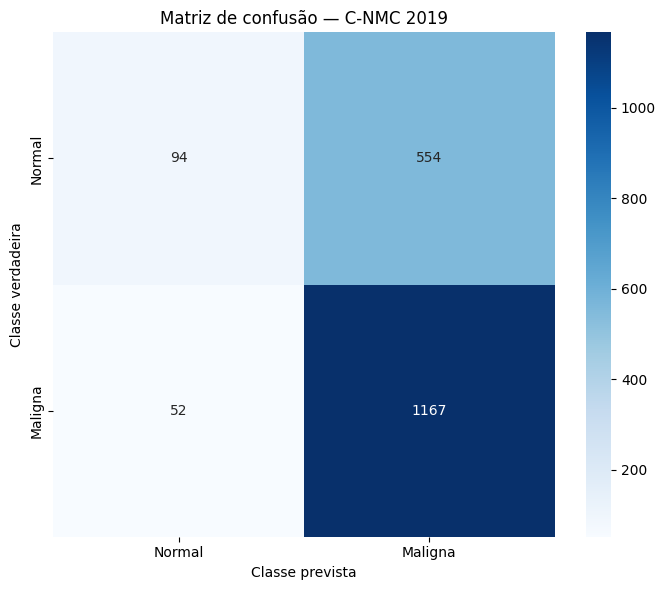

Matriz salva em: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/figures/test_confusion_matrix.png


In [15]:
# Cell 30
final_test_predictions = (
    test_probabilities
    >= SELECTED_THRESHOLD
).astype(np.int32)

final_confusion_matrix = confusion_matrix(
    test_labels,
    final_test_predictions,
    labels=[0, 1],
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "Maligna",
    ],
    yticklabels=[
        "Normal",
        "Maligna",
    ],
)

plt.title(
    "Matriz de confusão — C-NMC 2019"
)
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.tight_layout()

confusion_matrix_path = (
    FIGURES_DIR
    / "test_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Matriz salva em:",
    confusion_matrix_path,
)

In [16]:
# Cell 31
test_results = test_df.copy()

test_results["true_label"] = test_labels
test_results["malignant_probability"] = (
    test_probabilities
)
test_results["predicted_label"] = (
    final_test_predictions
)

conditions = [
    (
        (test_results["true_label"] == 0)
        & (test_results["predicted_label"] == 0)
    ),
    (
        (test_results["true_label"] == 1)
        & (test_results["predicted_label"] == 1)
    ),
    (
        (test_results["true_label"] == 0)
        & (test_results["predicted_label"] == 1)
    ),
    (
        (test_results["true_label"] == 1)
        & (test_results["predicted_label"] == 0)
    ),
]

test_results["outcome"] = np.select(
    conditions,
    [
        "TN",
        "TP",
        "FP",
        "FN",
    ],
    default="unknown",
)

display(
    test_results[
        "outcome"
    ].value_counts()
)

predictions_path = (
    EXPERIMENT_DIR
    / "test_predictions.csv"
)

test_results.to_csv(
    predictions_path,
    index=False,
)

print(
    "Previsões salvas em:",
    predictions_path,
)

,count
outcome,
TP,1167
FP,554
TN,94
FN,52


Previsões salvas em: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/test_predictions.csv


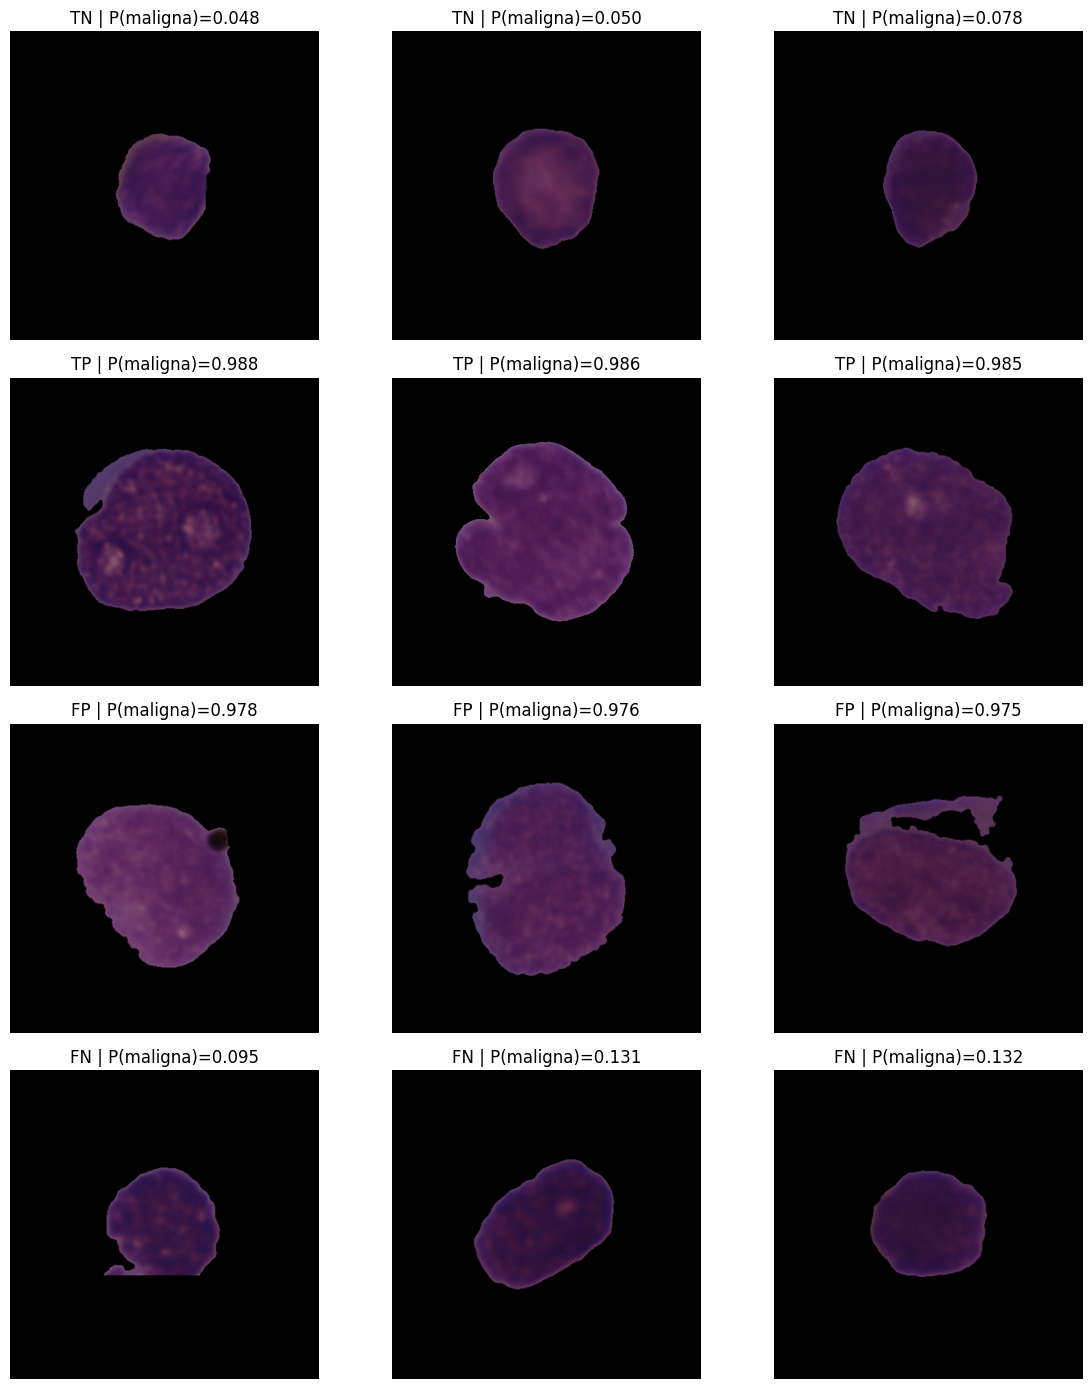

Exemplos salvos em: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/figures/test_success_and_error_examples.png


In [17]:
# Cell 32
example_groups = [
    (
        "TN",
        "Normal classificada corretamente",
        True,
    ),
    (
        "TP",
        "Maligna classificada corretamente",
        False,
    ),
    (
        "FP",
        "Normal classificada como maligna",
        False,
    ),
    (
        "FN",
        "Maligna classificada como normal",
        True,
    ),
]

EXAMPLES_PER_GROUP = 3

figure, axes = plt.subplots(
    len(example_groups),
    EXAMPLES_PER_GROUP,
    figsize=(12, 14),
)

for row, (
    outcome,
    row_title,
    ascending,
) in enumerate(example_groups):
    examples = (
        test_results[
            test_results["outcome"] == outcome
        ]
        .sort_values(
            "malignant_probability",
            ascending=ascending,
        )
        .head(EXAMPLES_PER_GROUP)
    )

    for column in range(EXAMPLES_PER_GROUP):
        axis = axes[row, column]

        if column >= len(examples):
            axis.axis("off")
            continue

        example = examples.iloc[column]

        image = tf.keras.utils.load_img(
            example["image_path"]
        )

        axis.imshow(image)
        axis.set_title(
            f"{outcome} | "
            f"P(maligna)="
            f"{example['malignant_probability']:.3f}"
        )
        axis.axis("off")

    axes[row, 0].set_ylabel(
        row_title,
        fontsize=10,
    )

plt.tight_layout()

examples_path = (
    FIGURES_DIR
    / "test_success_and_error_examples.png"
)

plt.savefig(
    examples_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Exemplos salvos em:",
    examples_path,
)

In [18]:
# Cell 33
import hashlib
import shutil


EXPORT_DIR = (
    EXPERIMENT_DIR
    / "export"
)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EXPORTED_MODEL_PATH = (
    EXPORT_DIR
    / "leukemia_efficientnet_b0.keras"
)

EXPORTED_WEIGHTS_PATH = (
    EXPORT_DIR
    / "leukemia_efficientnet_b0.weights.h5"
)

INFERENCE_CONFIG_PATH = (
    EXPORT_DIR
    / "inference_config.json"
)

TEST_METRICS_PATH = (
    EXPORT_DIR
    / "test_metrics.json"
)

shutil.copy2(
    SELECTED_MODEL_PATH,
    EXPORTED_MODEL_PATH,
)

selected_model.save_weights(
    EXPORTED_WEIGHTS_PATH
)

with TEST_METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_test_metrics,
        file,
        indent=2,
        ensure_ascii=False,
    )

inference_config = {
    "model_name": "EfficientNet-B0",
    "task": "binary_cell_classification",
    "input_scope": (
        "Imagem recortada de uma célula sanguínea"
    ),
    "image_size": [224, 224],
    "channels": 3,
    "color_mode": "RGB",
    "input_dtype": "float32",
    "input_pixel_range": [0, 255],
    "external_normalization": False,
    "normalization": (
        "Rescaling interno da EfficientNet-B0"
    ),
    "resize_method": "bilinear_antialias",
    "augmentation_during_inference": False,
    "class_mapping": {
        "0": "normal",
        "1": "malignant",
    },
    "positive_class": "malignant",
    "decision_threshold": (
        SELECTED_THRESHOLD
    ),
    "threshold_selection": (
    "Fixed threshold 0.5; "
    "sensitivity-prioritized proof of concept"
    ),
    "dataset": "C-NMC 2019",
    "selected_checkpoint": (
        SELECTED_MODEL_NAME
    ),
    "tensorflow_version": tf.__version__,
}

with INFERENCE_CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        inference_config,
        file,
        indent=2,
        ensure_ascii=False,
    )


def sha256(path):
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


print("Modelo:", EXPORTED_MODEL_PATH)
print("Pesos:", EXPORTED_WEIGHTS_PATH)
print("Configuração:", INFERENCE_CONFIG_PATH)
print("Métricas:", TEST_METRICS_PATH)
print(
    "SHA-256 do modelo:",
    sha256(EXPORTED_MODEL_PATH),
)

Modelo: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/export/leukemia_efficientnet_b0.keras
Pesos: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/export/leukemia_efficientnet_b0.weights.h5
Configuração: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/export/inference_config.json
Métricas: /content/drive/MyDrive/IT_2026/experiments/efficientnet_b0_cnmc/export/test_metrics.json
SHA-256 do modelo: fbad2b1ea8337d8d5b6b09ba4a4ea6da85528cbfabff5cd521fe2185c08e91d8


In [19]:
# Cell 34
print(
    "Limiar selecionado:",
    SELECTED_THRESHOLD,
)

print("\nMétricas finais:")

for metric, value in final_test_metrics.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

print("\nMatriz de confusão:")
print(final_confusion_matrix)

Limiar selecionado: 0.5

Métricas finais:
threshold: 0.5000
accuracy: 0.6754
precision: 0.6781
recall_sensitivity: 0.9573
specificity: 0.1451
balanced_accuracy: 0.5512
f1: 0.7939
auc: 0.6376
tn: 94
fp: 554
fn: 52
tp: 1167

Matriz de confusão:
[[  94  554]
 [  52 1167]]


In [20]:
# Cell 35
print("Limiar padrão 0.5:")

for metric, value in (
    metrics_default_threshold.items()
):
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

majority_baseline_accuracy = (
    test_df["label"]
    .value_counts(normalize=True)
    .max()
)

print(
    "\nBaseline da classe majoritária:",
    f"{majority_baseline_accuracy:.4f}",
)

probability_summary = (
    test_results
    .groupby("class_name")[
        "malignant_probability"
    ]
    .describe()
)

display(probability_summary)

Limiar padrão 0.5:
threshold: 0.5000
accuracy: 0.6754
precision: 0.6781
recall_sensitivity: 0.9573
specificity: 0.1451
balanced_accuracy: 0.5512
f1: 0.7939
auc: 0.6376
tn: 94
fp: 554
fn: 52
tp: 1167

Baseline da classe majoritária: 0.6529


,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
malignant,1219.0,0.821333,0.143722,0.094837,0.766325,0.864574,0.924171,0.988298
normal,648.0,0.730109,0.215800,0.048095,0.656899,0.805076,0.882395,0.978141


In [22]:
import hashlib
import json
from pathlib import Path

import pandas as pd


assert "selected_model" in globals(), (
    "selected_model não existe. Execute primeiro "
    "a célula que carrega o modelo e calcula o teste."
)

assert "validation_dataset" in globals(), (
    "validation_dataset não existe. Execute a "
    "célula que constrói os datasets."
)

assert "final_test_metrics" in globals(), (
    "final_test_metrics não existe. Execute a "
    "célula de avaliação do teste."
)


# Recalcula a validação sem retreinar.
validation_metrics = selected_model.evaluate(
    validation_dataset,
    return_dict=True,
    verbose=1,
)

validation_metrics = {
    metric: float(value)
    for metric, value
    in validation_metrics.items()
}


# Baseline da classe majoritária.
majority_class_baseline_accuracy = float(
    test_df["label"]
    .value_counts(normalize=True)
    .max()
)


# Distribuição das saídas por classe.
probability_dataframe = pd.DataFrame(
    {
        "class_name": test_df[
            "class_name"
        ].to_numpy(),
        "malignant_probability": (
            test_probabilities
        ),
    }
)

probability_summary = (
    probability_dataframe
    .groupby("class_name")[
        "malignant_probability"
    ]
    .describe()
)


# Diretório dos arquivos exportados.
EXPORT_DIR = Path(
    "/content/drive/MyDrive/IT_2026/"
    "experiments/efficientnet_b0_cnmc/"
    "export"
)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def calculate_sha256(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


model_sha256 = calculate_sha256(
    SELECTED_MODEL_PATH
)


evaluation_summary = {
    "selected_model": (
        SELECTED_MODEL_NAME
    ),
    "model_selection_metric": (
        "validation_auc"
    ),
    "validation_metrics": (
        validation_metrics
    ),
    "selected_threshold": float(
        SELECTED_THRESHOLD
    ),
    "threshold_selection": (
        "Fixed threshold 0.5; "
        "sensitivity-prioritized "
        "proof of concept"
    ),
    "test_metrics": (
        final_test_metrics
    ),
    "majority_class_baseline_accuracy": (
        majority_class_baseline_accuracy
    ),
    "probability_summary_by_class": (
        json.loads(
            probability_summary.to_json(
                orient="index"
            )
        )
    ),
    "model_sha256": model_sha256,
}

EVALUATION_SUMMARY_PATH = (
    EXPORT_DIR
    / "evaluation_summary.json"
)

with EVALUATION_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        evaluation_summary,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(
    json.dumps(
        evaluation_summary,
        indent=2,
        ensure_ascii=False,
    )
)

print(
    "\nResumo salvo em:",
    EVALUATION_SUMMARY_PATH,
)

112/112 ━━━━━━━━━━━━━━━━━━━━ 32s 153ms/step - accuracy: 0.7909 - auc: 0.8016 - loss: 0.4840 - precision: 0.7943 - recall: 0.9414
{
  "selected_model": "finetuned",
  "model_selection_metric": "validation_auc",
  "validation_metrics": {
    "accuracy": 0.7908809185028076,
    "auc": 0.8015904426574707,
    "loss": 0.48402392864227295,
    "precision": 0.7942994236946106,
    "recall": 0.9413919448852539
  },
  "selected_threshold": 0.5,
  "threshold_selection": "Fixed threshold 0.5; sensitivity-prioritized proof of concept",
  "test_metrics": {
    "threshold": 0.5,
    "accuracy": 0.6754151044456347,
    "precision": 0.6780941313190005,
    "recall_sensitivity": 0.9573420836751435,
    "specificity": 0.14506172839506173,
    "balanced_accuracy": 0.5512019060351027,
    "f1": 0.7938775510204081,
    "auc": 0.6376330527957546,
    "tn": 94,
    "fp": 554,
    "fn": 52,
    "tp": 1167
  },
  "majority_class_baseline_accuracy": 0.6529191215854312,
  "probability_summary_by_class": {
    "m

## Resultado final do módulo de LLA-B

O modelo selecionado foi a EfficientNet-B0 após fine-tuning parcial,
pois apresentou AUC de 0,8016 na validação, superior aos 0,7883 obtidos
com o backbone congelado.

No teste preliminar da C-NMC 2019, o modelo apresentou AUC de 0,6376.
Foi adotado o limiar padrão de 0,5, priorizando a sensibilidade e a
redução de falsos negativos. Foram obtidos:

- acurácia: 0,6754;
- precisão: 0,6781;
- sensibilidade: 0,9573;
- especificidade: 0,1451;
- F1-score: 0,7939;
- acurácia balanceada: 0,5512;
- falsos negativos: 52;
- falsos positivos: 554.

A elevada sensibilidade foi acompanhada por baixa especificidade,
indicando tendência a classificar imagens normais como malignas.
O módulo constitui uma prova de conceito experimental para sinalização
de imagens suspeitas e não realiza diagnóstico clínico.